# run_beta_compute.ipynb
This is meant to be the file that generates results for first beta paper

In [1]:
########################## Import statements ###########################
# Make sure to have the following packages installed:
#     1) matplotlib
#     2) numpy
#     3) pandas
#     4) obspy
#     5) tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

import importlib
from pathlib import Path

from beta_compute import BetaEstimator
from tqdm import trange

import os
import time
import string
from scipy.stats import binned_statistic

from matplotlib.patches import Rectangle

REPO_PATH = Path(os.getcwd())

print(f"REPO_PATH: {REPO_PATH}")

REPO_PATH: /Users/ivandevert/prog/py-nfi


In [2]:
def boxplot(x, y, xbins, ax=None, color='r', **kwargs):
    if ax is None:
        ax = plt.gca()

    x = np.asarray(x)
    y = np.asarray(y)

    # filter to values within bin range
    mask = (x >= xbins[0]) & (x <= xbins[-1])
    x, y = x[mask], y[mask]

    inds = np.digitize(x, bins=xbins) - 1
    # digitize returns len(xbins)-1 for x == xbins[-1]; clamp to last bin
    inds = np.clip(inds, 0, len(xbins) - 2)

    unique_inds = np.unique(inds)
    xmids = (xbins[1:] + xbins[:-1]) / 2
    xwidth = xbins[1] - xbins[0]

    X = [y[inds == i] for i in unique_inds]

    defaults = {
        'positions': xmids[unique_inds],
        'manage_ticks': False,
        'widths': xwidth * 0.8,
        'sym': '',
        'whis': (5, 95),
        'boxprops': dict(color=color),
        'medianprops': dict(color=color, linewidth=2),
        'whiskerprops': dict(color=color),
        'capprops': dict(color=color),
    }
    # **kwargs overrides **defaults
    return ax.boxplot(X, **{**defaults, **kwargs})

def scale_invar_total_lsq(x, y):
    """
    Scale-invariant total least squares / Standardized Major Axis (SMA)
    / Reduced Major Axis regression.

    This fits the unique line that is scale-invariant and symmetric in x,y:
        slope = sign(r) * (std_y / std_x)
        intercept = mean_y - slope * mean_x

    Parameters
    ----------
    x : array_like
    y : array_like

    Returns
    -------
    slope : float
    intercept : float
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    # Means and stds
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)

    # Correlation
    r = np.corrcoef(x, y)[0, 1]

    # SMA / RMA slope
    slope = np.sign(r) * (std_y / std_x)

    # Intercept
    intercept = mean_y - slope * mean_x

    return slope, intercept

def diff(arr):
    assert len(arr)==2, 'uh oh'
    return arr[1] - arr[0]

## Program parameters

In [3]:

# Required signal-to-noise ratio
stn_req = 3.0

# Signal-to-noise ratio testing band (Hz)
stn_band = (2.667, 6.0)

f_nyquist = 50.0

# Set paths
project_dir     = REPO_PATH / "ridgecrest"
figure_dir      = project_dir / "figures"

p_results_dir           = f"{project_dir}/p_results/"
s_results_dir           = f"{project_dir}/s_results/"
p_spectra_dir           = f"{project_dir}/data/spectra/p/"
s_spectra_dir           = f"{project_dir}/data/spectra/s/"
inv_dir                 = f"{project_dir}/inv/"

# Parent folder for synthetic results
synthetic_results_dir   = f"{project_dir}/synthetic_results/"


# Location of earthquake catalog containing stress drop estimates
delsig_p_catalog_path = f"{project_dir}/data/comparison_datasets/vandevert_2024_p.txt"
delsig_s_catalog_path = f"{project_dir}/data/comparison_datasets/vandevert_2024_s.txt"

# Synthetic P-wave results paths
brune_results_filepath          = f"{synthetic_results_dir}/brune/all_params.txt"
ss17_results_filepath           = f"{synthetic_results_dir}/ss17/all_params.txt"
ss17_noise_results_filepath     = f"{synthetic_results_dir}/ss17_noise/all_params.txt"
brune_noise_results_filepath    = f"{synthetic_results_dir}/brune_noise/all_params.txt"


# Synthetic S-wave results paths
brune_s_results_filepath        = f"{synthetic_results_dir}/brune_s/all_params.txt"
ss17_s_results_filepath         = f"{synthetic_results_dir}/ss17_s/all_params.txt"
ss17_s_noise_results_filepath   = f"{synthetic_results_dir}/ss17_s_noise/all_params.txt"
brune_s_noise_results_filepath  = f"{synthetic_results_dir}/brune_s_noise/all_params.txt"

# Make output directories if they don't exist
for pth in [p_results_dir, synthetic_results_dir, figure_dir, inv_dir]:
    if not os.path.exists(pth): os.makedirs(pth)

event_catalog_path = project_dir / "data/catalogs/trugman_relocated_catalog.txt"
station_catalog_path = project_dir / "data/catalogs/station_catalog.txt"



In [4]:
# Figure parameters

c_real = 'k'
c_ss17_noise = '#E1481E' # red
c_ss17 = "#0b36f4"  # blue
c_brune = '#A91EE1' # purple
c_brune_noise = "#27F580" # green

#########
cm = plt.cm.plasma
colors = cm(np.linspace(0.0, 1.0, 256))
cmap = mcolors.LinearSegmentedColormap.from_list('asdf', colors)

#########
cm_gray = plt.cm.Greys_r
colors_gray = cm_gray(np.linspace(0.1, .75, 256))
cmap_gray = mcolors.LinearSegmentedColormap.from_list('asdf', colors_gray)

vmin, vmax = 1, 6
cnorm_gray = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
smap_gray = mpl.cm.ScalarMappable(norm=cnorm_gray, cmap=cmap_gray)

cnorm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

scatter_mag_kw = {
    'marker':'.',
    'edgecolors': 'none',
    'norm': cnorm,
    'cmap': cmap,
}
scatter_mag_gray_kw = {
    'marker':'.',
    'edgecolors': 'none',
    'norm': cnorm_gray,
    'cmap': cmap_gray,
}
syn_plt_kw = {
    'lw': 1.5,
    'ls': '-',
    'zorder': 1000
}

In [5]:
from os.path import join
# Load arrays
print("Loading arrays...", end='')
t0 = time.time()
p_spectra = np.load(join(p_spectra_dir, "s2.npy"))
noise   = np.load(join(p_spectra_dir, "s1.npy"))
event_names  = np.load(join(p_spectra_dir, "event_names.npy"), allow_pickle=True)
channel_names = np.load(join(p_spectra_dir, "channel_names.npy"), allow_pickle=True)
deldist      = np.load(join(p_spectra_dir, "deldist.npy"))
print(f"Done. t = {time.time()-t0:,.2f} seconds.")

# create dataframe
print("Creating records DataFrame...", end='')
df_p = pd.DataFrame({
    'event_name': event_names,
    'channel_name': channel_names,
    'deldist': deldist
})
print(f"Done. N = {len(df_p):,} records.")

nf = p_spectra.shape[1]
f = np.linspace(0, f_nyquist, nf)

# Import event and station catalogs and merge into df_p
print("Loading catalogs...", end='')
df_catalog = pd.read_csv(event_catalog_path, sep='\\s+')
df_stations = pd.read_csv(station_catalog_path)

df_catalog['edt'] = df_catalog['origin_date'] + 'T' + df_catalog['origin_time']
df_catalog['edatetime'] = pd.to_datetime(df_catalog['edt'])
df_catalog = df_catalog[['event_name', 'edatetime', 'emag', 'elon', 'elat', 'edep']]
df_p = df_p.merge(df_catalog, how='left', on='event_name')

# merge station info
df_p = df_p.merge(df_stations, how='left', on='channel_name')
print(f"Done.")
print("")
print("------------------------------------------------")
print(f"Number of final records: {len(df_p):,}")
print(f"Number of final events: {len(df_p['event_name'].unique()):,}")

Loading arrays...Done. t = 0.38 seconds.
Creating records DataFrame...Done. N = 313,783 records.
Loading catalogs...Done.

------------------------------------------------
Number of final records: 313,783
Number of final events: 12,684


In [6]:
p_results = BetaEstimator(df_records=df_p, 
                          spectra=p_spectra, 
                          f=f, 
                          save_dir=p_results_dir,
                          compute_uncertainty=True,
                          calib_time_filter=False,
                          )
p_results = p_results.compute(recompute=False)

Initializing BetaEstimator
--------------------------
validate_input()
    |---> 0.0825 seconds

METADATA INFORMATION
----------------------------
Events:   12,684
Channels: 169
Records:  313,783

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.40 to 1.60
Calibration events:  1,906 (15.03%)
Calibration records: 37,362 (11.91%)

STATUS:
BetaEstimator initialized in 0.3983 s. Using 4 workers. Run 'compute()' to continue.
--------------------------------------------------------------------

Computing nFI
-----------------
Loading parameters from /Users/ivandevert/prog/py-nfi/ridgecrest/p_results//params.logbeta
Parameters unchanged from /Users/ivandevert/prog/py-nf

# S-wave computation

In [7]:
# Load arrays
print("Loading arrays...", end='')
t0 = time.time()
s_spectra = np.load(join(s_spectra_dir, "s2.npy"))
noise   = np.load(join(s_spectra_dir, "s1.npy"))
event_names  = np.load(join(s_spectra_dir, "event_names.npy"), allow_pickle=True)
channel_names = np.load(join(s_spectra_dir, "channel_names.npy"), allow_pickle=True)
deldist      = np.load(join(s_spectra_dir, "deldist.npy"))
print(f"Done. t = {time.time()-t0:,.2f} seconds.")

# create dataframe
print("Creating records DataFrame...", end='')
df_s = pd.DataFrame({
    'event_name': event_names,
    'channel_name': channel_names,
    'deldist': deldist
})
print(f"Done. N = {len(df_s):,} records.")

nf = s_spectra.shape[1]
f = np.linspace(0, f_nyquist, nf)

# Import event and station catalogs and merge into df_s
print("Loading catalogs...", end='')
df_catalog = pd.read_csv(event_catalog_path, sep='\\s+')
df_stations = pd.read_csv(station_catalog_path)

df_catalog['edt'] = df_catalog['origin_date'] + 'T' + df_catalog['origin_time']
df_catalog['edatetime'] = pd.to_datetime(df_catalog['edt'])
df_catalog = df_catalog[['event_name', 'edatetime', 'emag', 'elon', 'elat', 'edep']]
df_s = df_s.merge(df_catalog, how='left', on='event_name')

# merge station info
df_s = df_s.merge(df_stations, how='left', on='channel_name')
print(f"Done.")
print("")
print("------------------------------------------------")
print(f"Number of final records: {len(df_s):,}")
print(f"Number of final events: {len(df_s['event_name'].unique()):,}")

Loading arrays...Done. t = 1.49 seconds.
Creating records DataFrame...Done. N = 727,133 records.
Loading catalogs...Done.

------------------------------------------------
Number of final records: 727,133
Number of final events: 12,896


In [8]:
# # Load S-wave spectra
# print("Loading S-wave spectra...", end='')
# t0 = time.time()
# full_df_s = pd.read_parquet("/Users/ivandevert/prog/py-nfi/ridgecrest/data/spectra/s_spectra.parquet", engine="pyarrow")
# print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(full_df_s):,} records.")

# # Remove rows with irrelevant directions
# print("Removing directions other than N, E, 1, or 2...", end='')
# dirs = ['N', 'E', '1', '2']
# t0 = time.time()
# filtered_df = full_df_s.copy()
# filtered_df['direction'] = filtered_df['channel_name'].str[-1:]
# keep = [True if el in dirs else False for el in filtered_df['direction'].values]
# filtered_df = filtered_df[keep].reset_index(drop=True)
# filtered_df = filtered_df.drop('direction', axis=1)
# print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(filtered_df):,} records remaining.")


# # Make a copy
# df_s = filtered_df.copy()

# # Make the frequency array (assumed to be the same for all records)
# nf = len(df_s['s2'].values[0])
# f = np.linspace(0, f_nyquist, nf)

# # Filter out low-STN records
# print("Filtering out low-STN records...", end='')
# t0 = time.time()
# stn_i1 = np.argmin(np.abs(f - stn_band[0]))
# stn_i2 = np.argmin(np.abs(f - stn_band[1]))

# spectra = np.array(df_s['s2'].tolist(), dtype=float)
# noise = np.array(df_s['s1'].tolist(), dtype=float)

# # Compute STN
# df_s['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# # Drop records with low STN
# df_s = df_s[df_s['stn'] > stn_req].reset_index(drop=True)
# print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(df_s):,} records remaining.")

# s_spectra = np.array(df_s['s2'].tolist(), dtype=float)

# # # Drop unnecessary columns
# # df_s.drop(columns=['s1'], inplace=True)

# df_pga = df_s.copy()

# print("------------------------------------------------")
# print(f"Number of original records: {len(full_df_s):,}")
# print(f"Number of final records: {len(df_s):,}")
# print(f"\nNumber of original events: {len(full_df_s['event_name'].unique()):,}")
# print(f"Number of final events: {len(df_s['event_name'].unique()):,}")

In [9]:
s_results = BetaEstimator(df_records=df_s, 
                          spectra=s_spectra, 
                          f=f, 
                          calib_mag_range=(1.9, 2.1), 
                          save_dir=s_results_dir,
                          compute_uncertainty=True,
                          calib_time_filter=False,)
s_results = s_results.compute(recompute=False)

Initializing BetaEstimator
--------------------------
validate_input()
    |---> 0.4259 seconds

METADATA INFORMATION
----------------------------
Events:   12,896
Channels: 313
Records:  727,133

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.90 to 2.10
Calibration events:  1,193 (9.25%)
Calibration records: 79,022 (10.87%)

STATUS:
BetaEstimator initialized in 1.3248 s. Using 4 workers. Run 'compute()' to continue.
--------------------------------------------------------------------

Computing nFI
-----------------
Loading parameters from /Users/ivandevert/prog/py-nfi/ridgecrest/s_results//params.logbeta
Parameters unchanged from /Users/ivandevert/prog/py-nfi

# Load synthetic results from files for comparison
Synthetic results generated in synthetic_tests.ipynb

In [10]:
# P-wave synthetics
df_syn_brune        = pd.read_csv(brune_results_filepath)
df_syn_ss17         = pd.read_csv(ss17_results_filepath)
df_syn_ss17_noise   = pd.read_csv(ss17_noise_results_filepath)
df_syn_brune_noise  = pd.read_csv(brune_noise_results_filepath)

# S-wave synthetics
df_syn_brune_s        = pd.read_csv(brune_s_results_filepath)
df_syn_ss17_s         = pd.read_csv(ss17_s_results_filepath)
df_syn_ss17_s_noise   = pd.read_csv(ss17_s_noise_results_filepath)
df_syn_brune_s_noise  = pd.read_csv(brune_s_noise_results_filepath)

df_syn_brune = df_syn_brune.sort_values(by='emag').reset_index(drop=True)
df_syn_ss17 = df_syn_ss17.sort_values(by='emag').reset_index(drop=True)
df_syn_ss17_noise = df_syn_ss17_noise.sort_values(by='emag').reset_index(drop=True)
df_syn_brune_noise = df_syn_brune_noise.sort_values(by='emag').reset_index(drop=True)


df_syn_brune_s = df_syn_brune_s.sort_values(by='emag').reset_index(drop=True)
df_syn_ss17_s = df_syn_ss17_s.sort_values(by='emag').reset_index(drop=True)
df_syn_ss17_s_noise = df_syn_ss17_s_noise.sort_values(by='emag').reset_index(drop=True)
df_syn_brune_s_noise = df_syn_brune_s_noise.sort_values(by='emag').reset_index(drop=True)


edges = np.arange(1.0, 7.3, 0.2)
midpoints = (edges[1:] + edges[:-1]) / 2
brune_median_dlogbeta, _, _ = binned_statistic(df_syn_brune['emag'], df_syn_brune['dlogbeta'], statistic='median', bins=edges)
ss17_median_dlogbeta, _, _ = binned_statistic(df_syn_ss17['emag'], df_syn_ss17['dlogbeta'], statistic='median', bins=edges)
ss17_noise_median_dlogbeta, _, _ = binned_statistic(df_syn_ss17_noise['emag'], df_syn_ss17_noise['dlogbeta'], statistic='median', bins=edges)
brune_noise_median_dlogbeta, _, _ = binned_statistic(df_syn_brune_noise['emag'], df_syn_brune_noise['dlogbeta'], statistic='median', bins=edges)

brune_s_median_dlogbeta, _, _ = binned_statistic(df_syn_brune_s['emag'], df_syn_brune_s['dlogbeta'], statistic='median', bins=edges)
ss17_s_median_dlogbeta, _, _ = binned_statistic(df_syn_ss17_s['emag'], df_syn_ss17_s['dlogbeta'], statistic='median', bins=edges)
ss17_s_noise_median_dlogbeta, _, _ = binned_statistic(df_syn_ss17_s_noise['emag'], df_syn_ss17_s_noise['dlogbeta'], statistic='median', bins=edges)
brune_s_noise_median_dlogbeta, _, _ = binned_statistic(df_syn_brune_s_noise['emag'], df_syn_brune_s_noise['dlogbeta'], statistic='median', bins=edges)

# For all of the above synthetic dataframes, rename column "dlogbeta_corr" to "nfi"
for DF in [df_syn_brune, df_syn_ss17, df_syn_ss17_noise, df_syn_brune_noise,
           df_syn_brune_s, df_syn_ss17_s, df_syn_ss17_s_noise, df_syn_brune_s_noise]:
    DF.rename(columns={'dlogbeta_corr': 'nfi'}, inplace=True)

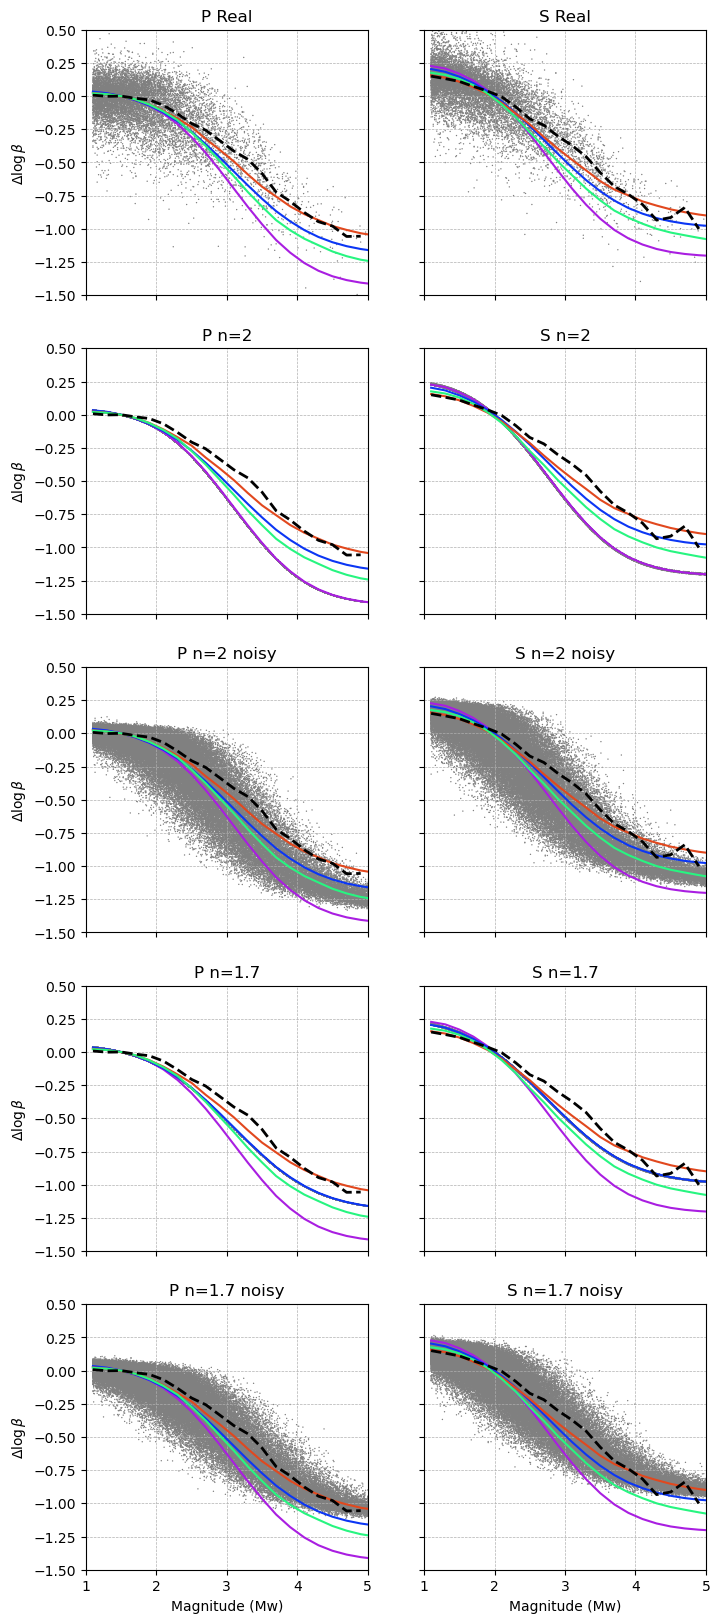

In [11]:
# Figure to display real and synthetic results, dlogbeta vs emag
dx = 0.2
edges = np.arange(1.0, 7.3, dx)
midpoints = (edges[1:] + edges[:-1]) / 2

p_medians, _, _ = binned_statistic(p_results.df_events['emag'], p_results.df_events['dlogbeta'], statistic='median', bins=edges)
s_medians, _, _ = binned_statistic(s_results.df_events['emag'], s_results.df_events['dlogbeta'], statistic='median', bins=edges)

R = [p_results.df_events, s_results.df_events,
     df_syn_brune, df_syn_brune_s,
     df_syn_brune_noise, df_syn_brune_s_noise,
     df_syn_ss17, df_syn_ss17_s,
     df_syn_ss17_noise, df_syn_ss17_s_noise]

modelname = ["Real", "Real", "n=2", "n=2", "n=2 noisy", "n=2 noisy", "n=1.7", "n=1.7", "n=1.7 noisy", "n=1.7 noisy"]

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(8, 20), sharex=True, sharey=True)

for i, d in enumerate(R):
    ax = axs.flatten()[i]
    x = d['emag']
    y = d['dlogbeta']

    ax.scatter(x=x, y=y, c='grey', edgecolors='none', s=1, zorder=1)

    if i%2==0:
        ax.plot(midpoints, p_medians, c=c_real, lw=2, ls='--', label=r'Median real data', zorder=10000)
        ax.plot(midpoints, brune_median_dlogbeta, c=c_brune, label='Brune n=2', **syn_plt_kw)
        ax.plot(midpoints, ss17_median_dlogbeta, c=c_ss17, label='n=1.7', **syn_plt_kw)
        ax.plot(midpoints, ss17_noise_median_dlogbeta, c=c_ss17_noise, label='n=1.7 noisy', **syn_plt_kw)
        ax.plot(midpoints, brune_noise_median_dlogbeta, c=c_brune_noise, label='n=2 noisy', **syn_plt_kw)

    else:
        ax.plot(midpoints, s_medians, c=c_real, lw=2, ls='--', label=r'Median real data', zorder=10000)
        ax.plot(midpoints, brune_s_median_dlogbeta, c=c_brune, label='Brune n=2', **syn_plt_kw)
        ax.plot(midpoints, ss17_s_median_dlogbeta, c=c_ss17, label='n=1.7', **syn_plt_kw)
        ax.plot(midpoints, ss17_s_noise_median_dlogbeta, c=c_ss17_noise, label='n=1.7 noisy', **syn_plt_kw)
        ax.plot(midpoints, brune_s_noise_median_dlogbeta, c=c_brune_noise, label='n=2 noisy', **syn_plt_kw)

    phase = "P" if i%2==0 else "S"

    ax.set_title(phase + " " + modelname[i])
    ax.set_xlim(1.0, 5.0)
    ax.set_ylim(-1.5, 0.5)
    ax.grid(True, which='both', ls='--', lw=0.5)
    if i%2==0:
        ax.set_ylabel(r'$\Delta\log\beta$')
    if i >=8:
        ax.set_xlabel('Magnitude (Mw)')


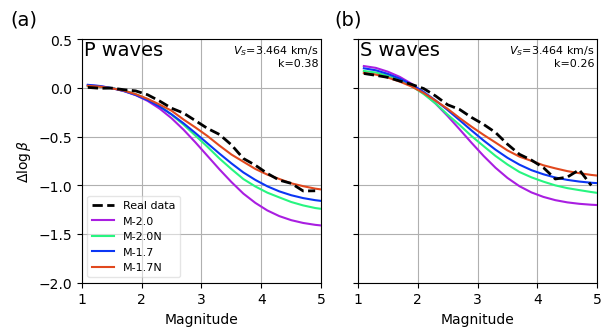

In [12]:
# Figure 8

from matplotlib.transforms import offset_copy

dx = 0.2
edges = np.arange(1.0, 7.3, dx)
ylim = np.array([-2, 0.5])

k_p = 0.38
k_s = 0.26
V_s = 3.464

# get midpoints
midpoints = (edges[1:] + edges[:-1]) / 2

# find median dlogbeta of real events in each bin
df_events = p_results.df_events
x = df_events['emag'].values
y = df_events['dlogbeta'].values

p_medians, _, _ = binned_statistic(x, y, statistic='median', bins=edges)

# S waves
df_events = s_results.df_events
x = df_events['emag'].values
y = df_events['dlogbeta'].values

s_medians, _, _ = binned_statistic(x, y, statistic='median', bins=edges)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[6,3.25], sharex=True, sharey=True, layout='constrained')

axs[0].plot(midpoints, p_medians, c=c_real, lw=2, ls='--', label=r'Real data', zorder=10000)

# Synthetic curves
axs[0].plot(midpoints, brune_median_dlogbeta, c=c_brune, label='M-2.0', **syn_plt_kw)
axs[0].plot(midpoints, brune_noise_median_dlogbeta, c=c_brune_noise, label='M-2.0N', **syn_plt_kw)
axs[0].plot(midpoints, ss17_median_dlogbeta, c=c_ss17, label='M-1.7', **syn_plt_kw)
axs[0].plot(midpoints, ss17_noise_median_dlogbeta, c=c_ss17_noise, label='M-1.7N', **syn_plt_kw)

axs[0].set_ylim(ylim)
axs[0].set_xlim((1,5))
axs[0].set_xlabel('Magnitude')
axs[0].set_ylabel(r'$\Delta\log\beta$')
axs[0].grid(True)
axs[0].legend(loc='lower left', fontsize=8, framealpha=0.5)
axs[0].annotate('P waves', xy=(0.01,0.995), xycoords='axes fraction', ha='left', va='top', fontsize=14)

# S waves
axs[1].plot(midpoints, s_medians, c=c_real, lw=2, ls='--', label=r'Real data', zorder=10000)

# Synthetic curves
axs[1].plot(midpoints, brune_s_median_dlogbeta, c=c_brune, label='M-2.0', **syn_plt_kw)
axs[1].plot(midpoints, brune_s_noise_median_dlogbeta, c=c_brune_noise, label='M-2.0N', **syn_plt_kw)
axs[1].plot(midpoints, ss17_s_median_dlogbeta, c=c_ss17, label='M-1.7', **syn_plt_kw)
axs[1].plot(midpoints, ss17_s_noise_median_dlogbeta, c=c_ss17_noise, label='M-1.7N', **syn_plt_kw)

# axs[1].set_ylim(ylim)
# axs[1].set_xlim((1,5))

axs[1].set_xlabel('Magnitude')
# axs[1].set_ylabel(r'$\Delta\log\beta$')
axs[1].grid(True)
# axs[1].legend(loc='lower left', fontsize=8, framealpha=0.5)
axs[1].annotate('S waves', xy=(0.01,0.995), xycoords='axes fraction', ha='left', va='top', fontsize=14)

axs[0].text(0.99, 0.985, r"$V_S$" + f"={V_s:.3f} km/s\n" + f"k={k_p:.2f}", transform=axs[0].transAxes, 
    size=8, zorder=10000, verticalalignment='top', horizontalalignment='right')
axs[1].text(0.99, 0.985, r"$V_S$" + f"={V_s:.3f} km/s\n" + f"k={k_s:.2f}", transform=axs[1].transAxes, 
    size=8, zorder=10000, verticalalignment='top', horizontalalignment='right')
    
trans = offset_copy(axs[0].transAxes, fig=fig, x=0, y=8, units='points')
axs[0].text(
    -0.30, 1.0,
    f"({string.ascii_lowercase[0]})",
    transform=trans,
    fontsize=14, ha='left', va='bottom'
)
trans = offset_copy(axs[1].transAxes, fig=fig, x=0, y=8, units='points')
axs[1].text(
    -0.10, 1.0,
    f"({string.ascii_lowercase[1]})",
    transform=trans,
    fontsize=14, ha='left', va='bottom'
)
plt.savefig(figure_dir / f"fig8.png", bbox_inches='tight')
plt.show()

In [13]:
len(p_results.df_events)

n1 = 1
n2 = 99

print("Statistics for nfi:")

# print the n1 and n2 percentile values of nfi
print(f"\nP-waves: n={len(p_results.df_events)}")
print(f"{n1}-th percentile: {np.percentile(p_results.df_events['nfi'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(p_results.df_events['nfi'].values, n2):.4f}")
print(f"STD: {np.std(p_results.df_events['nfi'].values):.4f}")
print(f"Median uncertainty (std): {np.median(p_results.df_events['dlogbeta_std'].values):.4f}")
print(f"STD of uncertainty: {np.std(p_results.df_events['dlogbeta_std'].values):.4f}")

# same for s-waves
print(f"\nS-waves: n={len(s_results.df_events)}")
print(f"{n1}-th percentile: {np.percentile(s_results.df_events['nfi'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(s_results.df_events['nfi'].values, n2):.4f}")
print(f"STD: {np.std(s_results.df_events['nfi'].values):.4f}")

# # synthetic results for comparison
print(f"\nSynthetic Brune: n={len(df_syn_brune)}")
print(f"{n1}-th percentile: {np.percentile(df_syn_brune['nfi'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(df_syn_brune['nfi'].values, n2):.4f}")

print(f"\nSynthetic SS17: n={len(df_syn_ss17)}")
print(f"{n1}-th percentile: {np.percentile(df_syn_ss17['nfi'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(df_syn_ss17['nfi'].values, n2):.4f}")

print(f"\nSynthetic SS17 with noise and delsig scatter: n={len(df_syn_ss17_noise)}")
print(f"{n1}-th percentile: {np.percentile(df_syn_ss17_noise['nfi'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(df_syn_ss17_noise['nfi'].values, n2):.4f}")


Statistics for nfi:

P-waves: n=10717
1-th percentile: -0.4581
99-th percentile: 0.3206
STD: 0.1559
Median uncertainty (std): 0.2397
STD of uncertainty: 0.0155

S-waves: n=11277
1-th percentile: -0.4141
99-th percentile: 0.3578
STD: 0.1475

Synthetic Brune: n=93249
1-th percentile: -0.0080
99-th percentile: 0.0023

Synthetic SS17: n=93249
1-th percentile: -0.0063
99-th percentile: 0.0027

Synthetic SS17 with noise and delsig scatter: n=93249
1-th percentile: -0.2988
99-th percentile: 0.2607


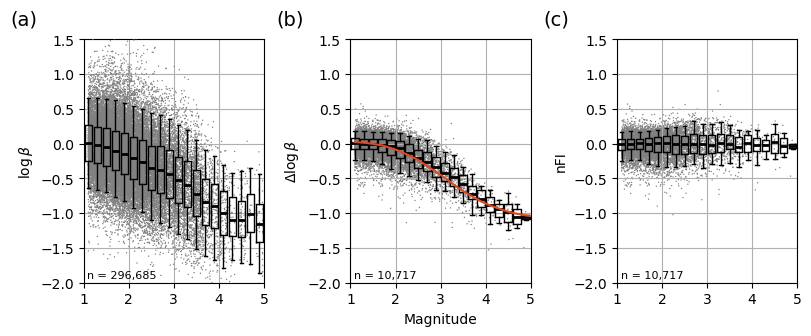

In [14]:
# Figure 3

# Corrections for all records, not just a single station
from matplotlib.patches import Rectangle
import string


# for i, row in df_sta.iterrows():
#     print(i, row['channel_name'], len(row['event_name']))

df_records = p_results.df_records
df_events = p_results.df_events
df_channels = p_results.df_channels

chname = "CI.SRT..HHZ"

df_single = df_channels[df_channels['channel_name'] == chname].reset_index(drop=True)


phase = "p"
# find index of the station of interest

dx = 0.2
edges = np.arange(1.0, 7.3, dx)
# ylim = np.array([-1.5, 2.0])
ylim = np.array([-2, 1.5])

calib_mag_range = p_results.calib_mag_range

median_kwargs = {"edgecolor":'r', "s":30, "marker":'s', 
               "zorder":100, "facecolor":'none', "linewidth":1}

fig, axs = plt.subplots(1,3, figsize=[8,3.25], sharex=True, sharey=False, layout='constrained')

x = df_records['emag'].values[::10]
y = df_records['logbeta'].values[::10]

# axs[0].scatter(df_records['emag'], df_records['logbeta'], c='k', s=0.2, edgecolors='none', label=r'$\log\beta$', zorder=10)
axs[0].scatter(x, y, c='grey', s=1, edgecolors='none', label=r'$\log\beta$', zorder=10)
boxplot(df_records['emag'], df_records['logbeta'], xbins=edges, ax=axs[0], color=c_real, zorder=101)


axs[1].scatter(df_events['emag'], df_events['dlogbeta'], c='grey', s=1, edgecolors='none', label=r'$\Delta\log\beta$', zorder=1)
boxplot(df_events['emag'], df_events['dlogbeta'], xbins=edges, ax=axs[1], color=c_real, zorder=2)


axs[2].scatter(df_events['emag'], df_events['nfi'], c='grey', s=1, edgecolors='none', label=r'$\Delta\log\beta^*$')
boxplot(df_events['emag'], df_events['nfi'], xbins=edges, ax=axs[2], color=c_real)


# # Synthetic curves
axs[1].plot(midpoints, ss17_noise_median_dlogbeta, c=c_ss17_noise, label=r'SS $\omega=1.7$ noisy', **syn_plt_kw)

axs[0].text(0.019, 0.01, f"n = {len(df_records):,.0f}", transform=axs[0].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')
axs[1].text(0.019, 0.01, f"n = {len(df_events):,.0f}", transform=axs[1].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')
axs[2].text(0.019, 0.01, f"n = {len(df_events):,.0f}", transform=axs[2].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')


axs[0].set_xlim([1.0, 5])
axs[0].set_ylim(ylim)
axs[1].set_ylim(ylim)
axs[2].set_ylim(ylim)
axs[1].set_xlabel('Magnitude')
axs[0].set_ylabel(r'$\log\beta$')
axs[1].set_ylabel(r'$\Delta\log\beta$')
axs[2].set_ylabel(r'nFI')

axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

from matplotlib.transforms import offset_copy
for n, ax in enumerate(axs):
    
    trans = offset_copy(ax.transAxes, fig=fig, x=0, y=8, units='points')

    ax.text(
        -0.41, 1.0,
        f"({string.ascii_lowercase[n]})",
        transform=trans,
        fontsize=14, ha='left', va='bottom'
    )
plt.savefig(figure_dir / f"fig3a-c.pdf", bbox_inches='tight')
plt.show()

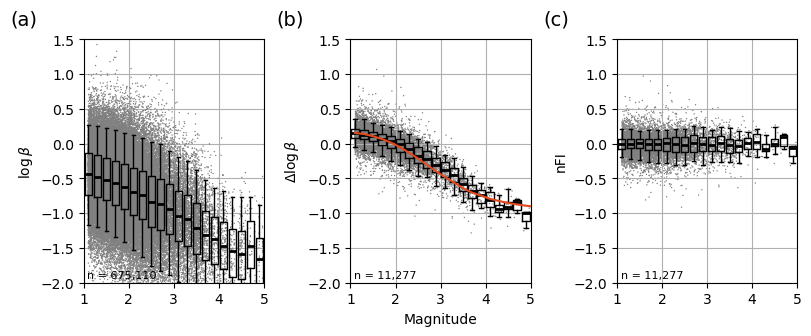

In [15]:
# Corrections for all records, not just a single station
from matplotlib.patches import Rectangle
import string


# for i, row in df_sta.iterrows():
#     print(i, row['channel_name'], len(row['event_name']))

df_records = s_results.df_records
df_events = s_results.df_events
df_channels = s_results.df_channels

chname = "CI.SRT..HHZ"

df_single = df_channels[df_channels['channel_name'] == chname].reset_index(drop=True)


phase = "p"
# find index of the station of interest

dx = 0.2
edges = np.arange(1.0, 7.3, dx)
# ylim = np.array([-1.5, 2.0])
ylim = np.array([-2, 1.5])

calib_mag_range = s_results.calib_mag_range

median_kwargs = {"edgecolor":'r', "s":30, "marker":'s', 
               "zorder":100, "facecolor":'none', "linewidth":1}

fig, axs = plt.subplots(1,3, figsize=[8,3.25], sharex=True, sharey=False, layout='constrained')

x = df_records['emag'].values[::10]
y = df_records['logbeta'].values[::10]

# axs[0].scatter(df_records['emag'], df_records['logbeta'], c='k', s=0.2, edgecolors='none', label=r'$\log\beta$', zorder=10)
axs[0].scatter(x, y, c='grey', s=1, edgecolors='none', label=r'$\log\beta$', zorder=10)
boxplot(df_records['emag'], df_records['logbeta'], xbins=edges, ax=axs[0], color=c_real, zorder=101)


axs[1].scatter(df_events['emag'], df_events['dlogbeta'], c='grey', s=1, edgecolors='none', label=r'$\Delta\log\beta$', zorder=1)
boxplot(df_events['emag'], df_events['dlogbeta'], xbins=edges, ax=axs[1], color=c_real, zorder=2)


axs[2].scatter(df_events['emag'], df_events['nfi'], c='grey', s=1, edgecolors='none', label=r'$\Delta\log\beta^*$')
boxplot(df_events['emag'], df_events['nfi'], xbins=edges, ax=axs[2], color=c_real)


# # Synthetic curves
axs[1].plot(midpoints, ss17_s_noise_median_dlogbeta, c=c_ss17_noise, label=r'SS $\omega=1.7$ noisy', **syn_plt_kw)


axs[0].text(0.019, 0.01, f"n = {len(df_records):,.0f}", transform=axs[0].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')
axs[1].text(0.019, 0.01, f"n = {len(df_events):,.0f}", transform=axs[1].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')
axs[2].text(0.019, 0.01, f"n = {len(df_events):,.0f}", transform=axs[2].transAxes, 
    size=8, zorder=10000, verticalalignment='bottom', horizontalalignment='left')


axs[0].set_xlim([1.0, 5])
axs[0].set_ylim(ylim)
axs[1].set_ylim(ylim)
axs[2].set_ylim(ylim)
axs[1].set_xlabel('Magnitude')
axs[0].set_ylabel(r'$\log\beta$')
axs[1].set_ylabel(r'$\Delta\log\beta$')
axs[2].set_ylabel(r'nFI')
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

from matplotlib.transforms import offset_copy
for n, ax in enumerate(axs):
    
    trans = offset_copy(ax.transAxes, fig=fig, x=0, y=8, units='points')

    ax.text(
        -0.41, 1.0,
        f"({string.ascii_lowercase[n]})",
        transform=trans,
        fontsize=14, ha='left', va='bottom'
    )
plt.savefig(figure_dir / f"SWave_fig3a-c.pdf", bbox_inches='tight')
plt.show()

In [16]:

P = p_results.df_events[p_results.ev_dep]
S = s_results.df_events[s_results.ev_dep]

df = pd.merge(P, S, how='outer', on=['event_name', 'elat', 'elon', 'edep', 'emag'], suffixes=('_p', '_s'))


# read in past results
cnames = ["event_name", "eyr", "emon", "eday", "ehr", "emn", "esc", "emag", 
          "elat", "elon", "edep", "nst", "negf", "fc", "delsig"]

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds = pd.merge(ds_p, ds_s, how='outer', on='event_name', suffixes=('_p', '_s')) # tested, works
print(f"{len(ds):,} unique events with stress drop estimates from Vandevert et al. 2024")

df = pd.merge(df, ds, how='left', on='event_name')

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)

# This fixes a bug where df doesn't groupby correctly when delsig is np.nan
df.loc[np.isnan(df['delsig_p']), 'delsig_p'] = 0
df.loc[np.isnan(df['delsig_s']), 'delsig_s'] = 0
df.loc[np.isnan(df['fc_p']), 'fc_p'] = 0
df.loc[np.isnan(df['fc_s']), 'fc_s'] = 0

y = ds_p['delsig'].values
logy = np.log10(y)
print("STD of P-wave delsig:", np.std(logy))

y = ds_s['delsig'].values
logy = np.log10(y)
print("STD of S-wave delsig:", np.std(logy))


6,827 unique events with stress drop estimates from Vandevert et al. 2024
STD of P-wave delsig: 0.7009948782997276
STD of S-wave delsig: 0.7526859379044787


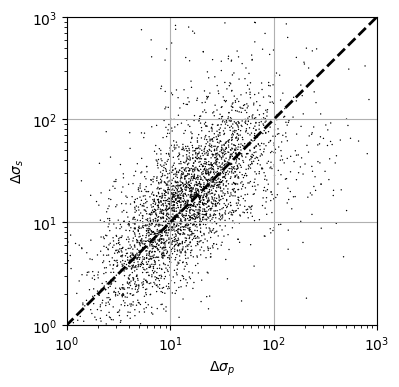

In [17]:
plt.figure(figsize=(4,4))
plt.scatter(df['delsig_p'], df['delsig_s'], c='k', s=1, edgecolors='none')
plt.xlabel(r'$\Delta\sigma_{p}$')
plt.ylabel(r'$\Delta\sigma_{s}$')
plt.xscale('log')
plt.yscale('log')
plt.plot([0.01, 1000], [0.01, 1000], 'k--', linewidth=2)
plt.xlim([1, 1000])
plt.ylim([1, 1000])
plt.grid(True)
plt.show()

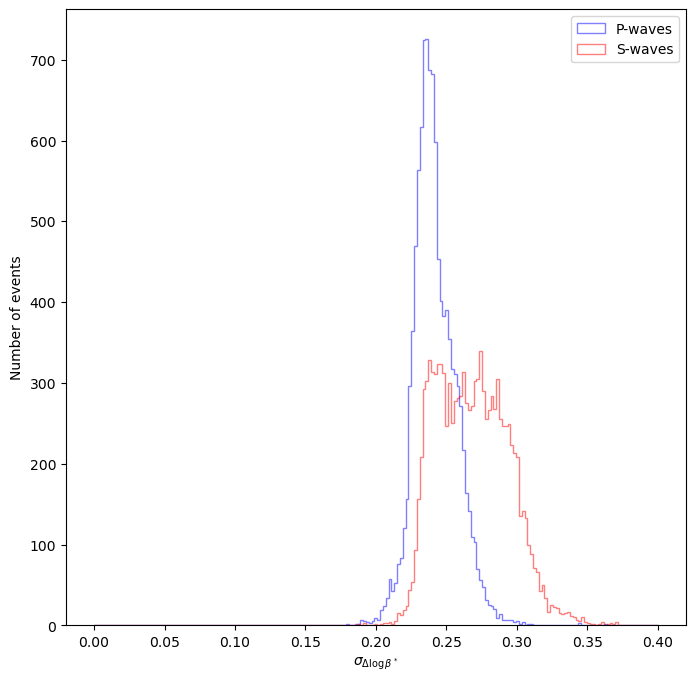

In [18]:
# visualize std of dlogbeta 
edges = np.linspace(0, 0.4, 200)

plt.figure(figsize=(8,8))
plt.hist(df['dlogbeta_std_p'].values, bins=edges, alpha=0.5, 
         label='P-waves', histtype='step', color='b')
plt.hist(df['dlogbeta_std_s'].values, bins=edges, alpha=0.5, 
         label='S-waves', histtype='step', color='r')

plt.xlabel(r"$\sigma_{\Delta\log\beta^*}$")
plt.ylabel('Number of events')
plt.legend()
plt.show()

Pearson correlation coefficient: 0.659
Standard deviation of residuals: 0.125
m = 0.945, b = 0.004


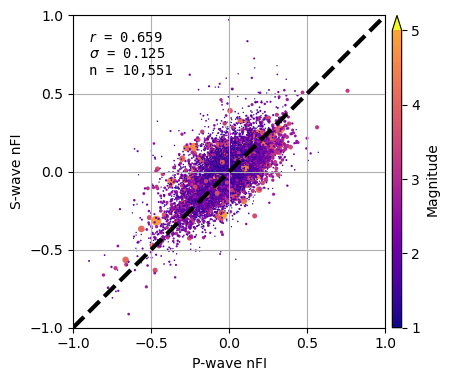

[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]
Magnitude range: 1.0 - 1.5, n=3,592, Pearson r = 0.535, N = 3,592
Magnitude range: 1.5 - 2.0, n=3,488, Pearson r = 0.661, N = 3,488
Magnitude range: 2.0 - 2.5, n=1,859, Pearson r = 0.736, N = 1,859
Magnitude range: 2.5 - 3.0, n=881, Pearson r = 0.743, N = 881
Magnitude range: 3.0 - 3.5, n=447, Pearson r = 0.727, N = 447
Magnitude range: 3.5 - 4.0, n=204, Pearson r = 0.670, N = 204
Magnitude range: 4.0 - 4.5, n=50, Pearson r = 0.646, N = 50
Magnitude range: 4.5 - 5.0, n=25, Pearson r = 0.610, N = 25


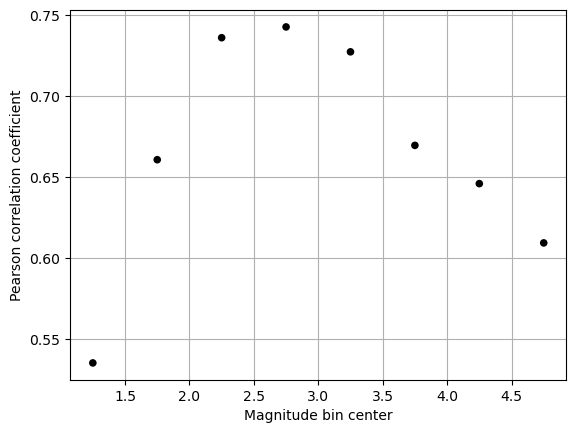

In [19]:
# Figure 4

import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable
xlim = [-1, 1]




keep = ~(np.isnan(df['nfi_p'].values) | np.isnan(df['nfi_s'].values))

# keep = keep & (df['emag'].values < 2.0)

# keep = keep & (df['dlogbeta_std_p'].values <0.15)
# keep = keep & (df['dlogbeta_std_s'].values <0.15)

pearson = scipy.stats.pearsonr(df['nfi_p'].values[keep], df['nfi_s'].values[keep])
residuals = df['nfi_s'].values[keep] - df['nfi_p'].values[keep]
mean_std = (df['dlogbeta_std_p'].values[keep] + df['dlogbeta_std_s'].values[keep]) / 2.0
std = np.std(residuals)
print(f"Pearson correlation coefficient: {pearson[0]:.3f}")
print(f"Standard deviation of residuals: {std:.3f}")


m, b = scale_invar_total_lsq(df['nfi_p'].values[keep], df['nfi_s'].values[keep])
print(f"m = {m:.3f}, b = {b:.3f}")

fig, ax = plt.subplots(1,1, figsize=(4,4), constrained_layout=True)
sc = ax.scatter(df['nfi_p'][keep], df['nfi_s'][keep], c=df['emag'][keep], s=3**df['emag'][keep], **scatter_mag_kw)
ax.plot(xlim, xlim, c='k', linestyle='--', lw=3)
ax.set_ylim(xlim)
ax.set_xlim(xlim)

X = np.linspace(-1, 1, 100)
Y = m * X + b
# ax.plot(X, Y, c='r', linewidth=2, ls='--')


# ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
# ax.set_ylabel(r"S-wave $\Delta\log\beta^*$")

ax.set_xlabel(r"P-wave nFI")
ax.set_ylabel(r"S-wave nFI")

ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True)
ax.set_aspect('equal')

# annotate with pearson and std upper left
ax.text(0.05, 0.95, f"$r$ = {pearson[0]:.3f}\n$\\sigma$ = {std:.3f}\nn = {len(df['nfi_p'].values[keep]):,}", 
    transform=ax.transAxes, verticalalignment='top', fontfamily='monospace')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=.07)

cbar = plt.colorbar(sc, cax=cax, extend='max', label='Magnitude')

cax.set_ylim([1, 5])

cax.set_yticks([1, 2, 3, 4, 5])

plt.savefig(f"{figure_dir}fig4.pdf", bbox_inches='tight')

plt.show()

# compute pearson correlation for events by magnitude bins
mags = df['emag'].values[keep]
dlogb_p = df['nfi_p'].values[keep]
dlogb_s = df['nfi_s'].values[keep]

mag_bins = np.arange(1.0, 7.2, 0.5)
print(mag_bins)

plt.figure()
for i in range(len(mag_bins)-1):
    mag_min = mag_bins[i]
    mag_max = mag_bins[i+1]
    sel = (mags >= mag_min) & (mags < mag_max)
    if np.sum(sel) > 2:
        pearson = scipy.stats.pearsonr(dlogb_p[sel], dlogb_s[sel])
        print(f"Magnitude range: {mag_min:.1f} - {mag_max:.1f}, n={np.sum(sel):,}, Pearson r = {pearson[0]:.3f}, N = {np.sum(sel):,}")
        plt.scatter((mag_min+mag_max)/2, pearson[0], c='k', s=30, edgecolors='none')
plt.grid()
plt.xlabel('Magnitude bin center')
plt.ylabel('Pearson correlation coefficient')
plt.show()

# plt.figure()
# plt.scatter(mean_std, np.abs(residuals), c='k', s=1, edgecolors='none')
# plt.xlim(0, 0.2)
# plt.xlabel('Mean standard deviation between P and S waves')
# plt.ylabel('Residuals')
# plt.show()

Pearson correlation coefficient: 0.605
Standard deviation of residuals: 0.122
Pearson correlation coefficient: 0.733
Standard deviation of residuals: 0.129
Pearson correlation coefficient: 0.634
Standard deviation of residuals: 0.145


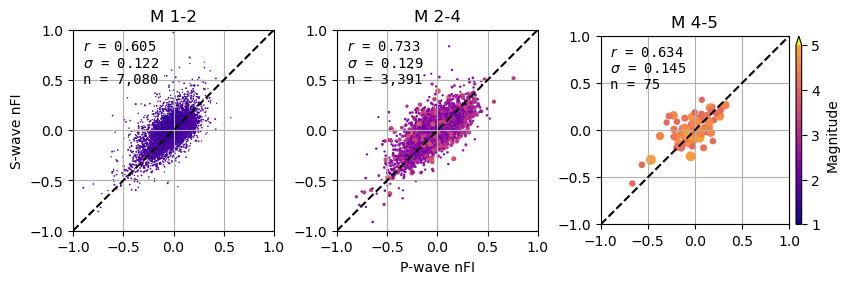

In [20]:
xlim = [-1, 1]

edges = np.array([1, 2, 4, 5], dtype=float)

fig, axs = plt.subplots(1,3, figsize=(8,3), constrained_layout=True)

for p in range(len(edges)-1):

    m_min = edges[p]
    m_max = edges[p+1]

    keep = ~(np.isnan(df['nfi_p'].values) | np.isnan(df['nfi_s'].values))

    keep = keep & (df['emag'].values < m_max) & (df['emag'].values >= m_min)

    # keep = keep & (df['dlogbeta_std_p'].values <0.2)
    # keep = keep & (df['dlogbeta_std_s'].values <0.2)

    pearson = scipy.stats.pearsonr(df['nfi_p'].values[keep], df['nfi_s'].values[keep])
    residuals = df['nfi_s'].values[keep] - df['nfi_p'].values[keep]
    std = np.std(residuals)
    print(f"Pearson correlation coefficient: {pearson[0]:.3f}")
    print(f"Standard deviation of residuals: {std:.3f}")


    ax = axs[p]
    sc = ax.scatter(df['nfi_p'][keep], df['nfi_s'][keep], c=df['emag'][keep], s=3**df['emag'][keep], **scatter_mag_kw)
    ax.plot(xlim, xlim, c='k', linestyle='--')
    ax.set_ylim(xlim)
    ax.set_xlim(xlim)


    # ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
    # ax.set_ylabel(r"S-wave $\Delta\log\beta^*$")



    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.grid(True)
    ax.set_aspect('equal')
    ax.set_title(f"M {int(m_min):1}-{int(m_max):1}")

    # annotate with pearson and std upper left
    ax.text(0.05, 0.95, f"$r$ = {pearson[0]:.3f}\n$\\sigma$ = {std:.3f}\nn = {len(df['nfi_p'].values[keep]):,}", 
        transform=ax.transAxes, verticalalignment='top', fontfamily='monospace')

axs[1].set_xlabel(r"P-wave nFI")
axs[0].set_ylabel(r"S-wave nFI")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax, extend='max', ticks=[1, 2, 3, 4, 5], label='Magnitude')
cax.set_ylim([1, 5])


plt.show()

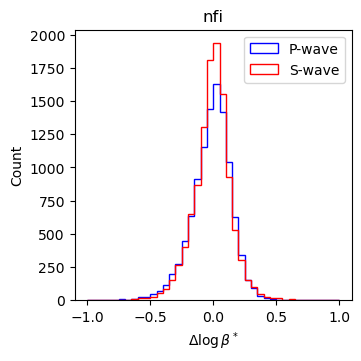

P-wave nfi
count    10717.000000
mean        -0.014882
std          0.155884
min         -1.020576
25%         -0.104508
50%          0.000279
75%          0.086738
max          0.758146
Name: nfi_p, dtype: float64
5% and 95% quantiles: 
 0.05   -0.293594
0.95    0.211931
Name: nfi_p, dtype: float64


S-wave nfi
count    11277.000000
mean        -0.009330
std          0.147492
min         -0.912838
25%         -0.086658
50%         -0.000714
75%          0.074756
max          0.972301
Name: nfi_s, dtype: float64
5% and 95% quantiles: 
 0.05   -0.257791
0.95    0.212751
Name: nfi_s, dtype: float64


In [21]:
# plot histogram of all nfi_p and nfi_s

fig, ax = plt.subplots(1,1, figsize=(3.5,3.5), constrained_layout=True)

ax.hist(df['nfi_p'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='P-wave', color='b')
ax.hist(df['nfi_s'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='S-wave', color='r')

ax.set_title(f'nfi')
ax.set_xlabel(r"$\Delta\log\beta^*$")
ax.set_ylabel('Count')
ax.legend()
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')

plt.show()

# print stats on each quantity (mean, median, std, min, max)
print("P-wave nfi")
print(df['nfi_p'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['nfi_p'].quantile([0.05, 0.95]))

print("\n\nS-wave nfi")
print(df['nfi_s'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['nfi_s'].quantile([0.05, 0.95]))

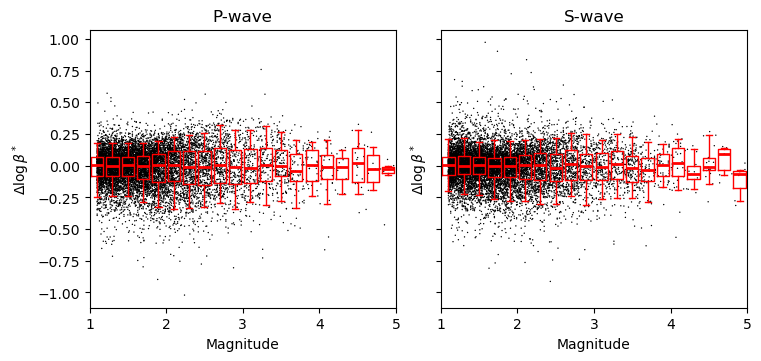

In [22]:
# plot nfi vs magnitude for P and S using boxplot

k1 = np.where(~np.isnan(df['nfi_p']))[0]
k2 = np.where(~np.isnan(df['nfi_s']))[0]



edges = np.arange(1.0, 7.3, 0.2)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)

ax1.scatter(df['emag'].values[k1], df['nfi_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['emag'].values[k2], df['nfi_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['emag'].values[k1], df['nfi_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['emag'].values[k2], df['nfi_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Magnitude')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.set_xlim([1, 5])
ax2.set_xlim([1, 5])

plt.show()

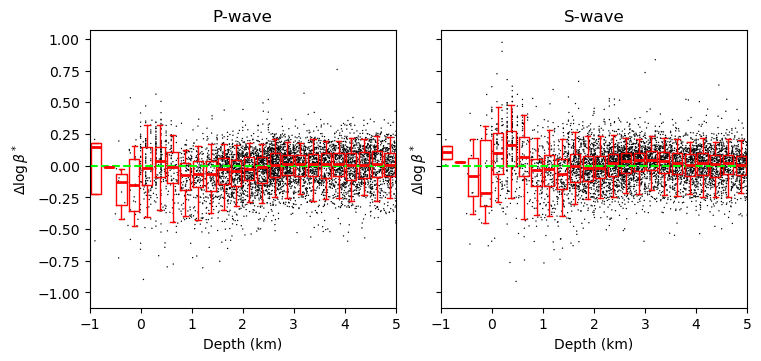

In [23]:
# plot nfi vs depth for P and S using boxplot

k1 = np.where(~np.isnan(df['nfi_p']))[0]
k2 = np.where(~np.isnan(df['nfi_s']))[0]



edges = np.arange(-1.0, 25, 0.25)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)




ax1.scatter(df['edep'].values[k1], df['nfi_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['edep'].values[k2], df['nfi_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['edep'].values[k1], df['nfi_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['edep'].values[k2], df['nfi_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Depth (km)')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Depth (km)')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.axhline(0, c='lime', ls='--')
ax2.axhline(0, c='lime', ls='--')



ax1.set_xlim([-1, 5])
ax2.set_xlim([-1, 5])

plt.show()

In [24]:
# find events within a fc range of the outer edges of the low and high beta windows
fc_low_range = [1, 2]
fc_high_range = [20, 24]

events_low_fc = df[np.logical_and(df['fc_p']>=fc_low_range[0], df['fc_p']<=fc_low_range[1])]
events_high_fc = df[np.logical_and(df['fc_p']>=fc_high_range[0], df['fc_p']<=fc_high_range[1])]

print(f"Mean, median magnitude of events with P-wave fc in low fc range: {np.mean(events_low_fc['emag']):.2f}, {np.median(events_low_fc['emag']):.2f}")
print(f"Mean, median magnitude of events with P-wave fc in high fc range: {np.mean(events_high_fc['emag']):.2f}, {np.median(events_high_fc['emag']):.2f}")


Mean, median magnitude of events with P-wave fc in low fc range: 5.10, 4.71
Mean, median magnitude of events with P-wave fc in high fc range: 1.97, 1.92


/Users/ivandevert/miniconda3/envs/nfi/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/nfi/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


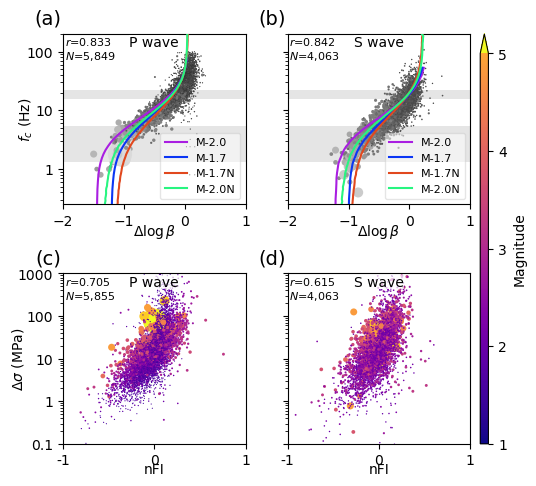

In [25]:
# Figure 5

# cmap = 'cividis'
# cmap = 'copper'



band_rect_kwargs = {
    'fill': True,
    'facecolor': 'grey',
    'alpha': 0.2,
    'edgecolor': 'none',
    'zorder': 0
}

eq_text_kw = {
    'x': 0.99,
    'y': 0.01,
    'ha': 'right',
    'va': 'bottom',
    'color': 'dimgrey',
    'fontsize': 8
}

param_text_kwargs = {
    'x': 0.01,
    'y': 0.99,
    'ha': 'left',
    'va': 'top',
    'color': 'k',
    'fontsize': 8
}

n_ind = 100
ind = np.linspace(0, len(df_syn_brune)-1, n_ind).astype(int)



std_max = 1
delsig_max = 1000

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(5.25,4.75),
    layout='constrained', sharex='row', sharey='row')


low_beta_window_p = p_results.low_window
low_beta_window_s = s_results.low_window

high_beta_window_p = p_results.high_window
high_beta_window_s = s_results.high_window



fcylim = [10**(-0.6), 200.0]
fcxlim = [-2, 1]
dsylim = [1E-1, 1E3]
dsxlim = [-1, 1]





keep3 = df['fc_p'] > 0
keep3 = keep3 & (~np.isnan(df['dlogbeta_p'])) & (~np.isnan(df['fc_p']))
keep3 = keep3 & (df['dlogbeta_std_p'] <= std_max)
keep3 = keep3 & (df['delsig_p'] <= delsig_max)

keep4 = df['fc_s'] > 0
keep4 = keep4 & (~np.isnan(df['dlogbeta_s'])) & (~np.isnan(df['fc_s']))
keep4 = keep4 & (df['dlogbeta_std_s'] <= std_max)
keep4 = keep4 & (df['delsig_s'] <= delsig_max)

x3 = df['dlogbeta_p'][keep3]
y3 = df['fc_p'][keep3]
c3 = df['emag'][keep3]
x4 = df['dlogbeta_s'][keep4]
y4 = df['fc_s'][keep4]
c4 = df['emag'][keep4]

rho3 = scipy.stats.pearsonr(x3, np.log10(y3))
rho4 = scipy.stats.pearsonr(x4, np.log10(y4))

# res = pg.sma_regression(x, y)
# print(res)

sc = ax[0,0].scatter(x3, y3, c=c3, s=.5*3**c3, **scatter_mag_gray_kw)
ax[0,1].scatter(x4, y4, c=c4, s=.5*3**c4, **scatter_mag_gray_kw)

# Show frequency bands as rectangles
ax[0,0].add_patch(Rectangle((-10, low_beta_window_p[0]), 20, diff(low_beta_window_p), **band_rect_kwargs))
ax[0,0].add_patch(Rectangle((-10, high_beta_window_p[0]), 20, diff(high_beta_window_p), **band_rect_kwargs))
ax[0,1].add_patch(Rectangle((-10, low_beta_window_s[0]), 20, diff(low_beta_window_s), **band_rect_kwargs))
ax[0,1].add_patch(Rectangle((-10, high_beta_window_s[0]), 20, diff(high_beta_window_s), **band_rect_kwargs))
ax[0,0].text(s=fr'$r$={rho3[0]:.3f}' + '\n' + fr'$N$={len(x3):,}', transform=ax[0,0].transAxes, **param_text_kwargs)
ax[0,1].text(s=fr'$r$={rho4[0]:.3f}' + '\n' + fr'$N$={len(x4):,}', transform=ax[0,1].transAxes, **param_text_kwargs)
ax[0,0].set_yscale('log')

ax[0,0].set_xlim(fcxlim)
ax[0,0].set_ylim(fcylim)
ax[0,0].set_yticks([1, 10, 100])
ax[0,0].set_yticklabels([1, 10, 100])

ax[0,0].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[0,1].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[0,0].set_ylabel(r"$f_c$ (Hz)", labelpad=-6)

# ax[0,0].set_title('P-wave')
# ax[0,1].set_title('S-wave')




keep = df['emag'] >= 0 # 1.5
keep = keep & (~np.isnan(df['nfi_p'])) & (~np.isnan(df['delsig_p'])) & (df['delsig_p']>0)
keep = keep & (df['dlogbeta_std_p'] <= std_max)
keep = keep & (df['delsig_p'] <= delsig_max)

x1 = df['nfi_p'][keep]
y1 = df['delsig_p'][keep]
c1 = df['emag'][keep]
std1 = df['dlogbeta_std_p'][keep]

keep = df['emag'] >= 0 # 2.0
keep = keep & (~np.isnan(df['nfi_s'])) & (~np.isnan(df['delsig_s'])) & (df['delsig_s']>0)
keep = keep & (df['dlogbeta_std_s'] <= std_max)
keep = keep & (df['delsig_s'] <= delsig_max)

x2 = df['nfi_s'][keep]
y2 = df['delsig_s'][keep]
c2 = df['emag'][keep]
std2 = df['dlogbeta_std_s'][keep]

mfit = 2.5
mmax = 5.0

keep1 = (c1.values > mfit) & (c1.values < mmax)
keep2 = (c2.values > mfit) & (c2.values < mmax)

m1, b1 = scale_invar_total_lsq(x1[keep1], np.log10(1E6 * y1[keep1]))
m2, b2 = scale_invar_total_lsq(x2[keep2], np.log10(1E6 * y2[keep2]))


rho1 = scipy.stats.pearsonr(x1, np.log10(1E6 * y1))
rho2 = scipy.stats.pearsonr(x2, np.log10(1E6 * y2))




sc = ax[1,0].scatter(x1, y1, c=c1, s=.5 * 3**c1, **scatter_mag_kw)
ax[1,1].scatter(x2, y2, c=c2, s=.5 * 3**c2, **scatter_mag_kw)

# X = np.array([-0.6, 0.6])
# ax[1,0].plot(X, 10**(m1*X + b1) / 1E6, color='k', linestyle='--', label=f'y={10**b1:.2f}x^{m1:.2f}')
# ax[1,1].plot(X, 10**(m2*X + b2) / 1E6, color='k', linestyle='--', label=f'y={10**b2:.2f}x^{m2:.2f}')



# # annotate lower right of each axis with the fit equation
# ax[1,0].text(s=fr'$\log_{{10}} \Delta \sigma$={m1:.2f}nFI + {b1:.2f}', transform=ax[1,0].transAxes, **eq_text_kw)
# ax[1,1].text(s=fr'$\log_{{10}} \Delta \sigma$={m2:.2f}nFI + {b2:.2f}', transform=ax[1,1].transAxes, **eq_text_kw)

# annotate upper left of each axis with the pearson correlation coefficient
ax[1,0].text(s=fr'$r$={rho1[0]:.3f}' + '\n' + fr'$N$={len(x1):,}', transform=ax[1,0].transAxes, **param_text_kwargs)
ax[1,1].text(s=fr'$r$={rho2[0]:.3f}' + '\n' + fr'$N$={len(x2):,}', transform=ax[1,1].transAxes, **param_text_kwargs)


ax[1,0].set_yscale('log')
ax[1,0].set_ylim(dsylim)

ax[1,0].set_xlim(dsxlim)
ax[1,0].set_xticks([-1, 0, 1])
ax[1,0].set_xticklabels([-1, 0, 1])
ax[1,0].set_xlabel(r"nFI", labelpad=-4)
ax[1,1].set_xlabel(r"nFI", labelpad=-4)
ax[1,0].set_ylabel(r"$\Delta\sigma$ (MPa)", labelpad=-6)
ax[1,0].set_yticks([0.1, 1, 10, 100, 1000])
ax[1,0].set_yticklabels([0.1, 1, 10, 100, 1000])




#### SYNTHETIC CURVES ####
# P-wave Brune synthetic curve
ax[0,0].plot(df_syn_brune['dlogbeta'].values[ind], df_syn_brune['fc'][ind], 
             color=c_brune, label='M-2.0', **syn_plt_kw)
# P-wave SS17 synthetic curve
ax[0,0].plot(df_syn_ss17['dlogbeta'][ind], df_syn_ss17['fc'][ind], 
             color=c_ss17, label='M-1.7', **syn_plt_kw)
# P-wave SS17 w/noise synthetic curve
x = df_syn_ss17_noise['dlogbeta'].values
y = df_syn_ss17_noise['fc'].values 
filt = np.isfinite(x) & np.isfinite(y)
x = x[filt]
y = y[filt]
bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,0].plot(median_dlogbeta, bin_centers, color=c_ss17_noise, label='M-1.7N', **syn_plt_kw)

# P-wave Brune w/noise synthetic curve
x = df_syn_brune_noise['dlogbeta'].values
y = df_syn_brune_noise['fc'].values 
filt = np.isfinite(x) & np.isfinite(y)
x = x[filt]
y = y[filt]
bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,0].plot(median_dlogbeta, bin_centers, color=c_brune_noise, label='M-2.0N', **syn_plt_kw)


# S-wave Brune synthetic curve
ax[0,1].plot(df_syn_brune_s['dlogbeta'].values[ind], df_syn_brune_s['fc'][ind], 
             color=c_brune, label='M-2.0', **syn_plt_kw)
# S-wave SS17 synthetic curve
ax[0,1].plot(df_syn_ss17_s['dlogbeta'][ind], df_syn_ss17_s['fc'][ind], 
             color=c_ss17, label='M-1.7', **syn_plt_kw)
# S-wave SS17 w/noise synthetic curve
x = df_syn_ss17_s_noise['dlogbeta'].values
y = df_syn_ss17_s_noise['fc'].values 
filt = np.isfinite(x) & np.isfinite(y)
x = x[filt]
y = y[filt]

bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,1].plot(median_dlogbeta, bin_centers, color=c_ss17_noise, label='M-1.7N', **syn_plt_kw)

# S-wave Brune w/noise synthetic curve
x = df_syn_brune_s_noise['dlogbeta'].values
y = df_syn_brune_s_noise['fc'].values 
filt = np.isfinite(x) & np.isfinite(y)
x = x[filt]
y = y[filt]

bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,1].plot(median_dlogbeta, bin_centers, color=c_brune_noise, label='M-2.0N', **syn_plt_kw)


#### END SYNTHETIC CURVES ####


ax[0,0].legend(loc='lower right', fontsize=8, framealpha=0.5)
ax[0,1].legend(loc='lower right', fontsize=8, framealpha=0.5)



# # panel labels
# for n, axes in enumerate(ax.flatten()):
#     axes.text(0.90, 0.885, string.ascii_lowercase[n], transform=axes.transAxes, 
#         size=16)

from matplotlib.transforms import offset_copy
for n, axis in enumerate(ax.flatten()):
    
    trans = offset_copy(axis.transAxes, fig=fig, x=0, y=4, units='points')

    axis.text(
        -0.01, 1.0,
        f"({string.ascii_lowercase[n]})",
        transform=trans,
        fontsize=14, ha='right', va='bottom'
    )

cbar = fig.colorbar(sc, ax=ax[:,1], pad=0.03, label='Magnitude', aspect=50, extend='max')
cax = cbar.ax
cax.set_ylim([1, 5])
cax.set_yticks([1, 2, 3, 4, 5])

for n, axis in enumerate(ax.flatten()):
    if n in [0, 2]: 
        label = 'P wave'
    else:
        label = 'S wave'
    t = axis.text(s=label, x=0.5, y=0.99, ha='center', va='top', transform=axis.transAxes, fontsize=10, color='k')
    t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.1))
        
plt.savefig(f"{figure_dir}fig6a-d.pdf", bbox_inches='tight')
plt.show()




In [26]:
x = df_syn_ss17_noise['dlogbeta'].values
y = df_syn_ss17_noise['fc'].values 

filt = np.isfinite(x) & np.isfinite(y)


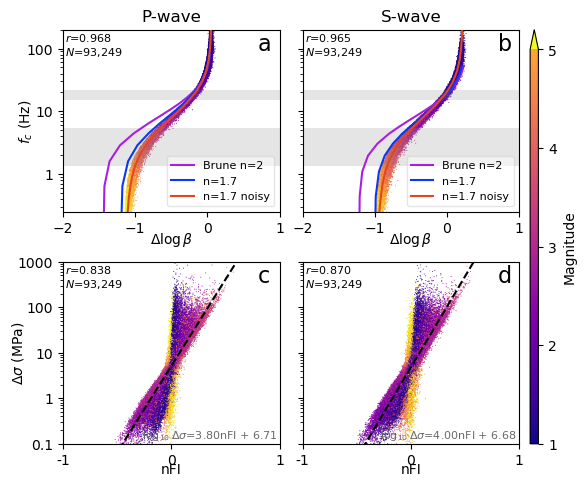

In [27]:
# SYNTHETIC ONLY version

# cmap = 'cividis'
# cmap = 'copper'

ev_dep_syn = ['event_name', 'emag', 'elon', 'elat', 'edep', 'nrec', 'm0', 'delsig']

ds_syn = df_syn_ss17_noise.merge(df_syn_ss17_s_noise, how='outer', suffixes=('_p', '_s'), on=ev_dep_syn)
# ds_syn = df_syn_brune_noise.merge(df_syn_brune_s_noise, how='outer', suffixes=('_p', '_s'), on=ev_dep_syn)
# ds_syn = df_syn_brune.merge(df_syn_brune_s, how='outer', suffixes=('_p', '_s'), on=ev_dep_syn)



band_rect_kwargs = {
    'fill': True,
    'facecolor': 'grey',
    'alpha': 0.2,
    'edgecolor': 'none'
}

eq_text_kw = {
    'x': 0.99,
    'y': 0.01,
    'ha': 'right',
    'va': 'bottom',
    'color': 'dimgrey',
    'fontsize': 8
}

param_text_kwargs = {
    'x': 0.01,
    'y': 0.99,
    'ha': 'left',
    'va': 'top',
    'color': 'k',
    'fontsize': 8
}

n_ind = 25
ind = np.linspace(0, len(df_syn_brune)-1, n_ind).astype(int)



std_max = 1


fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(5.75,4.75),
    layout='constrained', sharex='row', sharey='row')


low_beta_window_p = p_results.low_window
low_beta_window_s = s_results.low_window

high_beta_window_p = p_results.high_window
high_beta_window_s = s_results.high_window



fcylim = [10**(-0.6), 200.0]
fcxlim = [-2, 1]
dsylim = [1E-1, 1E3]
dsxlim = [-1, 1]


# df_syn_ss17_noise




keep3 = ds_syn['fc_p'] > 0
keep3 = keep3 & (~np.isnan(ds_syn['dlogbeta_p'])) & (~np.isnan(ds_syn['fc_p']))
# keep3 = keep3 & (ds_syn['dlogbeta_std_p'] <= std_max)
keep4 = ds_syn['fc_s'] > 0
keep4 = keep4 & (~np.isnan(ds_syn['dlogbeta_s'])) & (~np.isnan(ds_syn['fc_s']))
# keep4 = keep4 & (ds_syn['dlogbeta_std_s'] <= std_max)

x3 = ds_syn['dlogbeta_p'][keep3]
y3 = ds_syn['fc_p'][keep3]
c3 = ds_syn['emag'][keep3]
x4 = ds_syn['dlogbeta_s'][keep4]
y4 = ds_syn['fc_s'][keep4]
c4 = ds_syn['emag'][keep4]

rho3 = scipy.stats.pearsonr(x3, np.log10(y3))
rho4 = scipy.stats.pearsonr(x4, np.log10(y4))

# res = pg.sma_regression(x, y)
# print(res)

sc = ax[0,0].scatter(x3, y3, c=c3, s=2, **scatter_mag_kw)
ax[0,1].scatter(x4, y4, c=c4, s=2, **scatter_mag_kw)

# Show frequency bands as rectangles
ax[0,0].add_patch(Rectangle((-10, low_beta_window_p[0]), 20, diff(low_beta_window_p), **band_rect_kwargs))
ax[0,0].add_patch(Rectangle((-10, high_beta_window_p[0]), 20, diff(high_beta_window_p), **band_rect_kwargs))
ax[0,1].add_patch(Rectangle((-10, low_beta_window_s[0]), 20, diff(low_beta_window_s), **band_rect_kwargs))
ax[0,1].add_patch(Rectangle((-10, high_beta_window_s[0]), 20, diff(high_beta_window_s), **band_rect_kwargs))
ax[0,0].text(s=fr'$r$={rho3[0]:.3f}' + '\n' + fr'$N$={len(x3):,}', transform=ax[0,0].transAxes, **param_text_kwargs)
ax[0,1].text(s=fr'$r$={rho4[0]:.3f}' + '\n' + fr'$N$={len(x4):,}', transform=ax[0,1].transAxes, **param_text_kwargs)
ax[0,0].set_yscale('log')

ax[0,0].set_xlim(fcxlim)
ax[0,0].set_ylim(fcylim)
ax[0,0].set_yticks([1, 10, 100])
ax[0,0].set_yticklabels([1, 10, 100])

ax[0,0].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[0,1].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[0,0].set_ylabel(r"$f_c$ (Hz)", labelpad=-6)

ax[0,0].set_title('P-wave')
ax[0,1].set_title('S-wave')




keep = ds_syn['emag'] >= 1.0
keep = keep & (~np.isnan(ds_syn['nfi_p'])) & (~np.isnan(ds_syn['delsig'])) & (ds_syn['delsig']>0)
# keep = keep & (ds_syn['dlogbeta_std_p'] <= std_max)
x1 = ds_syn['nfi_p'][keep]
y1 = ds_syn['delsig'][keep]
c1 = ds_syn['emag'][keep]
# std1 = ds_syn['dlogbeta_std_p'][keep]

keep = ds_syn['emag'] >= 1.0
keep = keep & (~np.isnan(ds_syn['nfi_s'])) & (~np.isnan(ds_syn['delsig'])) & (ds_syn['delsig']>0)
# keep = keep & (ds_syn['dlogbeta_std_s'] <= std_max)
x2 = ds_syn['nfi_s'][keep]
y2 = ds_syn['delsig'][keep]
c2 = ds_syn['emag'][keep]
# std2 = ds_syn['dlogbeta_std_s'][keep]

mfit = 2.5
mmax = 4.0

keep1 = (c1.values > mfit) & (c1.values < mmax)
keep2 = (c2.values > mfit) & (c2.values < mmax)

m1, b1 = scale_invar_total_lsq(x1[keep1], np.log10(1E6 * y1[keep1]))
m2, b2 = scale_invar_total_lsq(x2[keep2], np.log10(1E6 * y2[keep2]))


rho1 = scipy.stats.pearsonr(x1, np.log10(1E6 * y1))
rho2 = scipy.stats.pearsonr(x2, np.log10(1E6 * y2))




# sc = ax[1,0].scatter(x1, y1, c=c1, s=.5 * 3**c1, **scatter_mag_kw)
sc = ax[1,0].scatter(x1, y1, c=c1, s=2, **scatter_mag_kw)
ax[1,1].scatter(x2, y2, c=c2, s=2, **scatter_mag_kw)

X = np.array([-0.8, 0.8])
ax[1,0].plot(X, 10**(m1*X + b1) / 1E6, color='k', linestyle='--', label=f'y={10**b1:.2f}x^{m1:.2f}')
ax[1,1].plot(X, 10**(m2*X + b2) / 1E6, color='k', linestyle='--', label=f'y={10**b2:.2f}x^{m2:.2f}')



# annotate lower right of each axis with the fit equation
ax[1,0].text(s=fr'$\log_{{10}} \Delta \sigma$={m1:.2f}nFI + {b1:.2f}', transform=ax[1,0].transAxes, **eq_text_kw)
ax[1,1].text(s=fr'$\log_{{10}} \Delta \sigma$={m2:.2f}nFI + {b2:.2f}', transform=ax[1,1].transAxes, **eq_text_kw)

# annotate upper left of each axis with the pearson correlation coefficient
ax[1,0].text(s=fr'$r$={rho1[0]:.3f}' + '\n' + fr'$N$={len(x1):,}', transform=ax[1,0].transAxes, **param_text_kwargs)
ax[1,1].text(s=fr'$r$={rho2[0]:.3f}' + '\n' + fr'$N$={len(x2):,}', transform=ax[1,1].transAxes, **param_text_kwargs)


ax[1,0].set_yscale('log')
ax[1,0].set_ylim(dsylim)

ax[1,0].set_xlim(dsxlim)
ax[1,0].set_xticks([-1, 0, 1])
ax[1,0].set_xticklabels([-1, 0, 1])
ax[1,0].set_xlabel(r"nFI", labelpad=-4)
ax[1,1].set_xlabel(r"nFI", labelpad=-4)
ax[1,0].set_ylabel(r"$\Delta\sigma$ (MPa)", labelpad=-6)
ax[1,0].set_yticks([0.1, 1, 10, 100, 1000])
ax[1,0].set_yticklabels([0.1, 1, 10, 100, 1000])




#### SYNTHETIC CURVES ####
# P-wave Brune synthetic curve
ax[0,0].plot(df_syn_brune['dlogbeta'].values[ind], df_syn_brune['fc'][ind], 
             color=c_brune, label='Brune n=2', **syn_plt_kw)
# P-wave SS17 synthetic curve
ax[0,0].plot(df_syn_ss17['dlogbeta'][ind], df_syn_ss17['fc'][ind], 
             color=c_ss17, label='n=1.7', **syn_plt_kw)
# P-wave SS17 w/noise synthetic curve
x = df_syn_ss17_noise['dlogbeta'].values
y = df_syn_ss17_noise['fc'].values 
bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,0].plot(median_dlogbeta, bin_centers, color=c_ss17_noise, label='n=1.7 noisy', **syn_plt_kw)



# S-wave Brune synthetic curve
ax[0,1].plot(df_syn_brune_s['dlogbeta'].values[ind], df_syn_brune_s['fc'][ind], 
             color=c_brune, label='Brune n=2', **syn_plt_kw)
# S-wave SS17 synthetic curve
ax[0,1].plot(df_syn_ss17_s['dlogbeta'][ind], df_syn_ss17_s['fc'][ind], 
             color=c_ss17, label='n=1.7', **syn_plt_kw)
# S-wave SS17 w/noise synthetic curve
x = df_syn_ss17_s_noise['dlogbeta'].values
y = df_syn_ss17_s_noise['fc'].values 
bin_edges = np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_ind)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_inds = np.digitize(y, bin_edges) - 1
median_dlogbeta = np.empty(len(bin_centers)) * np.nan
for i in range(len(bin_centers)):
    median_dlogbeta[i] = np.median(x[bin_inds==i])
ax[0,1].plot(median_dlogbeta, bin_centers, color=c_ss17_noise, label='n=1.7 noisy', **syn_plt_kw)
#### END SYNTHETIC CURVES ####


ax[0,0].legend(loc='lower right', fontsize=8, framealpha=0.5)
ax[0,1].legend(loc='lower right', fontsize=8, framealpha=0.5)



# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.90, 0.885, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)

cbar = fig.colorbar(sc, ax=ax[:,1], pad=0.03, label='Magnitude', aspect=50, extend='max')
cax = cbar.ax
cax.set_ylim([1, 5])
cax.set_yticks([1, 2, 3, 4, 5])
        
# plt.savefig(f"{figure_dir}fig6a-d-SYN-SS17.pdf", bbox_inches='tight')
# plt.savefig(f"{figure_dir}fig6a-d-SYN-SS17.png", bbox_inches='tight')

# plt.savefig(f"{figure_dir}fig6a-d-SYN-BRUNE.pdf", bbox_inches='tight')
# plt.savefig(f"{figure_dir}fig6a-d-SYN-BRUNE.png", bbox_inches='tight')
plt.show()

# Uncertainty

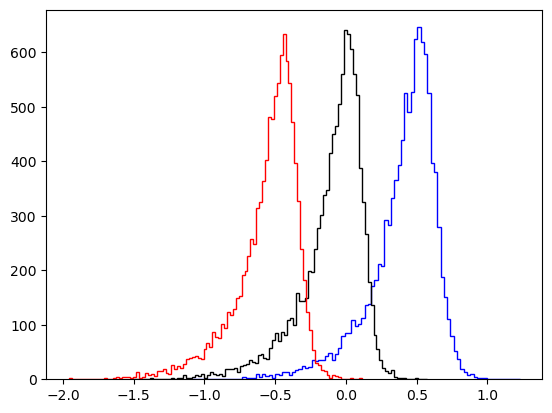

In [28]:
df_ev = p_results.df_events



plt.figure()
plt.hist(df_ev['dlogbeta_upper'], bins=100, color='b', histtype='step')
plt.hist(df_ev['dlogbeta'], bins=100, color='k', histtype='step')
plt.hist(df_ev['dlogbeta_lower'], bins=100, color='r', histtype='step')
plt.show()


